In [3]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, LeakyReLU
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU

In [4]:
# import kagglehub

# # https://www.kaggle.com/datasets/joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20(Multiclass)

# # Download latest version
# path1 = kagglehub.dataset_download("joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20")

# # https://www.kaggle.com/datasets/nafin59/monkeypox-skin-lesion-dataset
# # Download latest version
# path2 = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")


# print("Path to dataset files:", path1)
# print("Path to dataset files:", path2)

In [5]:
IMG_SIZE = (224, 224) # resolution
directory = "/kaggle/input/monkeypox-skin-lesion-dataset/Augmented Images/Augmented Images"
BATCH_SIZE = 32
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)

Found 3192 files belonging to 2 classes.
Using 2873 files for training.


I0000 00:00:1745386092.038812      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3192 files belonging to 2 classes.
Using 319 files for validation.


In [7]:
class_names = train_dataset.class_names
class_names

['Monkeypox_augmented', 'Others_augmented']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


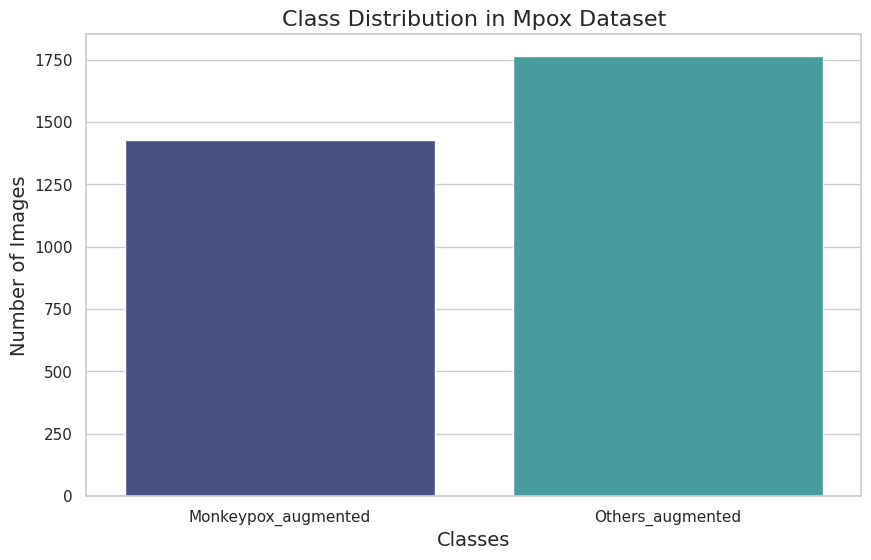

In [9]:
# Set seaborn theme
sns.set_theme(style="whitegrid")

# Get class names
class_names = train_dataset.class_names

# Count images in each class directory
Data_imbalance = []
for folder in class_names:
    files = gb.glob(pathname=os.path.join(directory, folder, "*.*"))
    Data_imbalance.append(len(files))

# Plot class imbalance
plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=Data_imbalance, palette="mako")
plt.title("Class Distribution in Mpox Dataset", fontsize=16)
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.show()


In [11]:
# Assuming Data_imbalance = [count_monkeypox, count_others]
total = sum(Data_imbalance)

weight_for_0 = (1 / Data_imbalance[0]) * (total / 2.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print('Weight for class 0 (Monkeypox): {:.2f}'.format(weight_for_0))
print('Weight for class 1 (Others): {:.2f}'.format(weight_for_1))

Weight for class 0 (Monkeypox): 1.12
Weight for class 1 (Others): 0.90


In [14]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

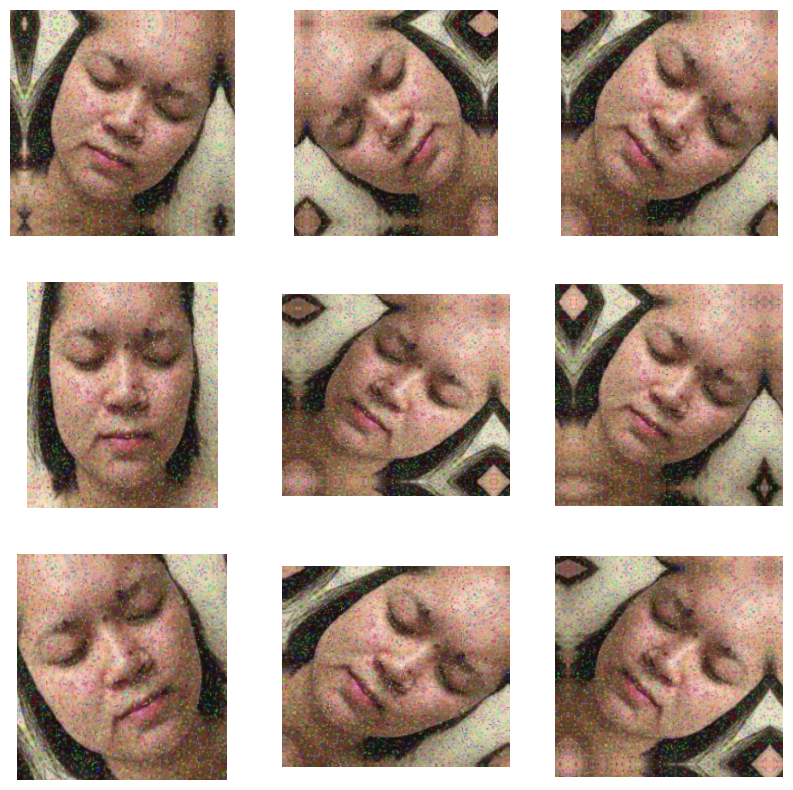

In [16]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

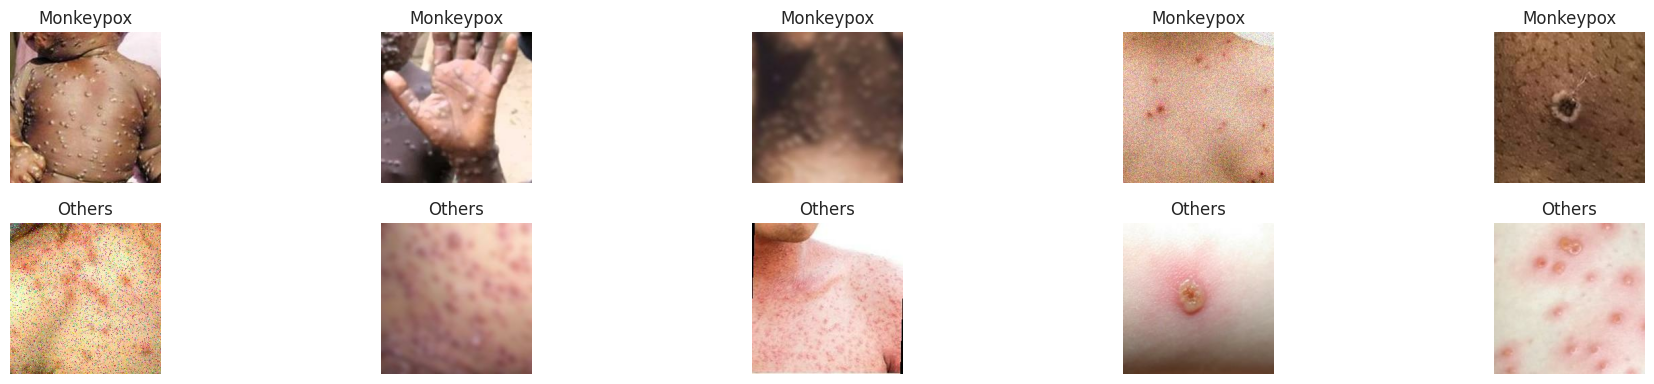

In [17]:
plt.figure(figsize=(20, 4))

Monkeypox_augmented = []
Others_augmented = []

# Get one batch from the training dataset
for images, labels in train_dataset.take(1):
    for image, label in zip(images, labels):
        label_name = class_names[label.numpy()]
        if label_name == "Monkeypox_augmented" and len(Monkeypox_augmented) < 5:
            Monkeypox_augmented.append(image.numpy().astype("uint8"))
        elif label_name == "Others_augmented" and len(Others_augmented) < 5:
            Others_augmented.append(image.numpy().astype("uint8"))
        if len(Monkeypox_augmented) == 5 and len(Others_augmented) == 5:
            break

# Plot Monkeypox samples
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(Monkeypox_augmented[i])
    plt.axis("off")
    plt.title("Monkeypox")

# Plot Others samples
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(Others_augmented[i])
    plt.axis("off")
    plt.title("Others")

plt.tight_layout()
plt.show()

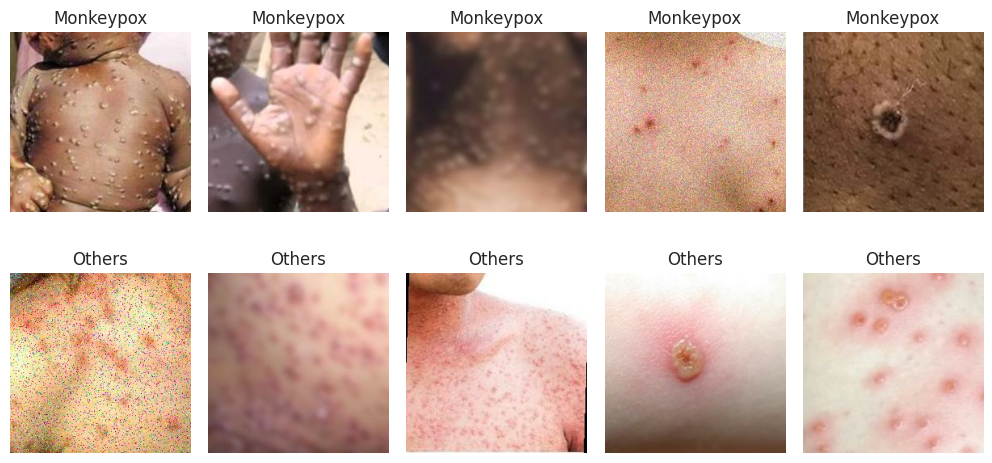

In [18]:
plt.figure(figsize=(20, 5))

# Determine number of samples to show per class
num_mpox = min(10, len(Monkeypox_augmented))
num_others = min(10, len(Others_augmented))

# Plot Monkeypox_augmented
for i in range(num_mpox):
    plt.subplot(2, 10, i + 1)
    plt.imshow(Monkeypox_augmented[i])
    plt.axis("off")
    plt.title("Monkeypox")

# Plot Others_augmented
for i in range(num_others):
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(Others_augmented[i])
    plt.axis("off")
    plt.title("Others")

plt.tight_layout()
plt.show()



In [19]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [22]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load the base VGG19 model
base_model = VGG19(input_shape=(224,224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

# Build the model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Add early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [23]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weight,
    callbacks=[early_stopping]
)

# Evaluate the model on the validation dataset
test_loss, test_accuracy = model.evaluate(validation_dataset)

print(f"\n✅ Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Testing Loss: {test_loss:.4f}")

Epoch 1/10


I0000 00:00:1745386395.810097     103 service.cc:148] XLA service 0x335f0d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745386395.810668     103 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745386396.308870     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/90 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.5078 - loss: 2.6345  

I0000 00:00:1745386404.587065     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 235ms/step - accuracy: 0.5184 - loss: 2.4120 - val_accuracy: 0.7586 - val_loss: 0.6440
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.6512 - loss: 1.2751 - val_accuracy: 0.7837 - val_loss: 0.4687
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7127 - loss: 0.8977 - val_accuracy: 0.8182 - val_loss: 0.4213
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7522 - loss: 0.7672 - val_accuracy: 0.8276 - val_loss: 0.3570
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7647 - loss: 0.6615 - val_accuracy: 0.8621 - val_loss: 0.3086
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7806 - loss: 0.5765 - val_accuracy: 0.8683 - val_loss: 0.2891
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8097 - loss: 0.4602 - val_accuracy: 0.8715 - val_loss: 0.2676
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8328 - loss: 0.4106 - val_accuracy: 0.8934 - val_loss: 

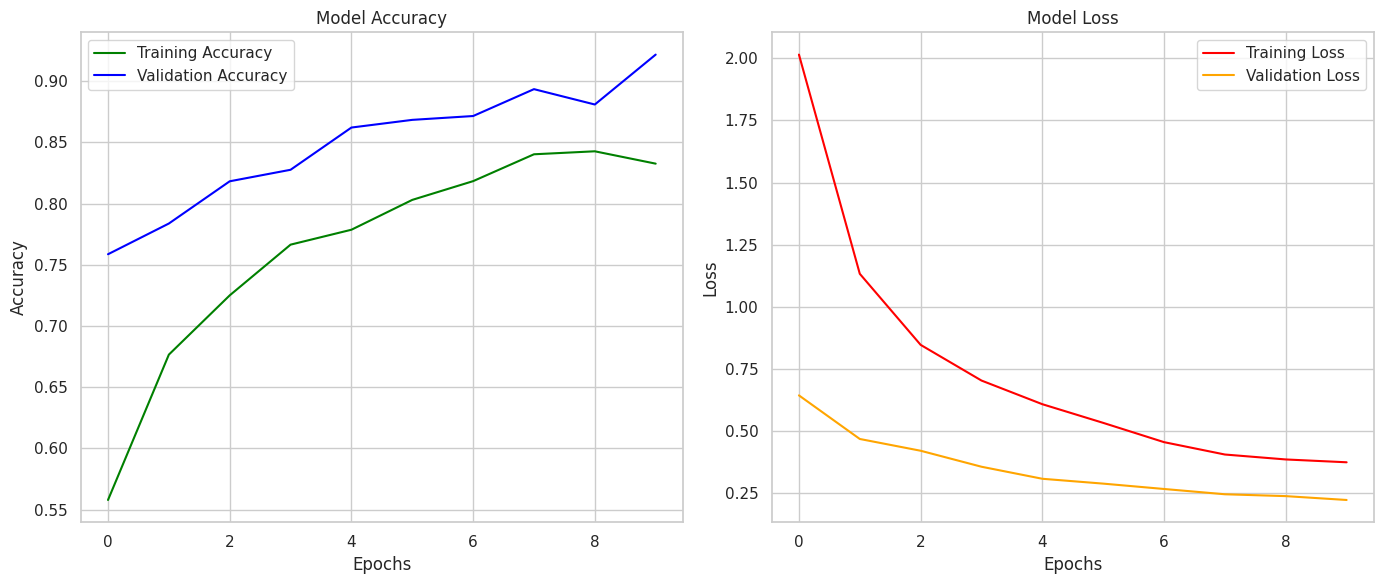

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


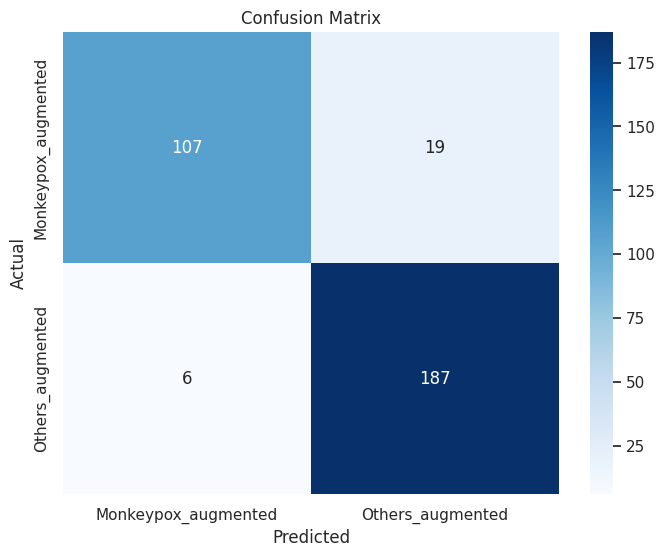

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

                     precision    recall  f1-score   support

Monkeypox_augmented       0.95      0.85      0.90       126
   Others_augmented       0.91      0.97      0.94       193

           accuracy                           0.92       319
          macro avg       0.93      0.91      0.92       319
       weighted avg       0.92      0.92      0.92       319

